In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading Data

df= pd.read_csv('/content/Student-Employability.csv')
df.head()

,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
0,Student 1,4,5,4,5,5,5,5,5,Employable
1,Student 2,4,4,4,4,4,4,3,5,Employable
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable
3,Student 4,3,3,3,2,3,3,3,5,LessEmployable
4,Student 5,4,4,3,3,4,4,3,5,Employable


In [ ]:
# Size of the dataset
print('Number of Rows: ',df.shape[0])
print('Number of Columns: ',df.shape[1])

Number of Rows:  2982
Number of Columns:  10


In [ ]:
df.rename(columns= {'SELF-CONFIDENCE': 'SELF CONFIDENCE',
                    'Student Performance Rating': 'STUDENT PERFORMANCE RATING'}, inplace= True)

In [ ]:
# Info about the Columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Name of Student             2982 non-null   object
 1   GENERAL APPEARANCE          2982 non-null   int64 
 2   MANNER OF SPEAKING          2982 non-null   int64 
 3   PHYSICAL CONDITION          2982 non-null   int64 
 4   MENTAL ALERTNESS            2982 non-null   int64 
 5   SELF CONFIDENCE             2982 non-null   int64 
 6   ABILITY TO PRESENT IDEAS    2982 non-null   int64 
 7   COMMUNICATION SKILLS        2982 non-null   int64 
 8   STUDENT PERFORMANCE RATING  2982 non-null   int64 
 9   CLASS                       2982 non-null   object
dtypes: int64(8), object(2)
memory usage: 233.1+ KB


In [ ]:
# Basic statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
GENERAL APPEARANCE,2982.0,4.246814,0.678501,2.0,4.0,4.0,5.0,5.0
MANNER OF SPEAKING,2982.0,3.884641,0.757013,2.0,3.0,4.0,4.0,5.0
PHYSICAL CONDITION,2982.0,3.972166,0.744135,2.0,3.0,4.0,5.0,5.0
MENTAL ALERTNESS,2982.0,3.962777,0.781982,2.0,3.0,4.0,5.0,5.0
SELF CONFIDENCE,2982.0,3.910798,0.807602,2.0,3.0,4.0,5.0,5.0
ABILITY TO PRESENT IDEAS,2982.0,3.813883,0.739390,2.0,3.0,4.0,4.0,5.0
COMMUNICATION SKILLS,2982.0,3.525486,0.743881,2.0,3.0,3.0,4.0,5.0
STUDENT PERFORMANCE RATING,2982.0,4.610664,0.692845,3.0,4.0,5.0,5.0,5.0


In [ ]:
# Checking Missing values
df.isnull().sum()

,0
Name of Student,0
GENERAL APPEARANCE,0
MANNER OF SPEAKING,0
PHYSICAL CONDITION,0
MENTAL ALERTNESS,0
SELF CONFIDENCE,0
ABILITY TO PRESENT IDEAS,0
COMMUNICATION SKILLS,0
STUDENT PERFORMANCE RATING,0
CLASS,0


There is no Missing Values in the dataset.

### Target Variable Distribtion

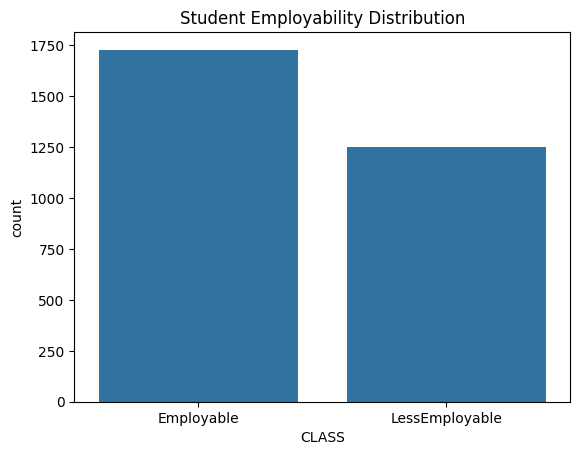

In [ ]:
sns.countplot(x='CLASS', data=df)
plt.title("Student Employability Distribution")
plt.show()

The dataset shows two classes: Employable and Less Employable. By this Visualisation, We can say that the class is imbalance.

In [ ]:
#df.drop('Name of Student', axis=1, inplace =True)
df['CLASS'] = df['CLASS'].map({'Employable': 1, 'LessEmployable': 0})

In [ ]:
df.head()

,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,STUDENT PERFORMANCE RATING,CLASS
0,Student 1,4,5,4,5,5,5,5,5,1
1,Student 2,4,4,4,4,4,4,3,5,1
2,Student 3,4,3,3,3,3,3,2,5,0
3,Student 4,3,3,3,2,3,3,3,5,0
4,Student 5,4,4,3,3,4,4,3,5,1


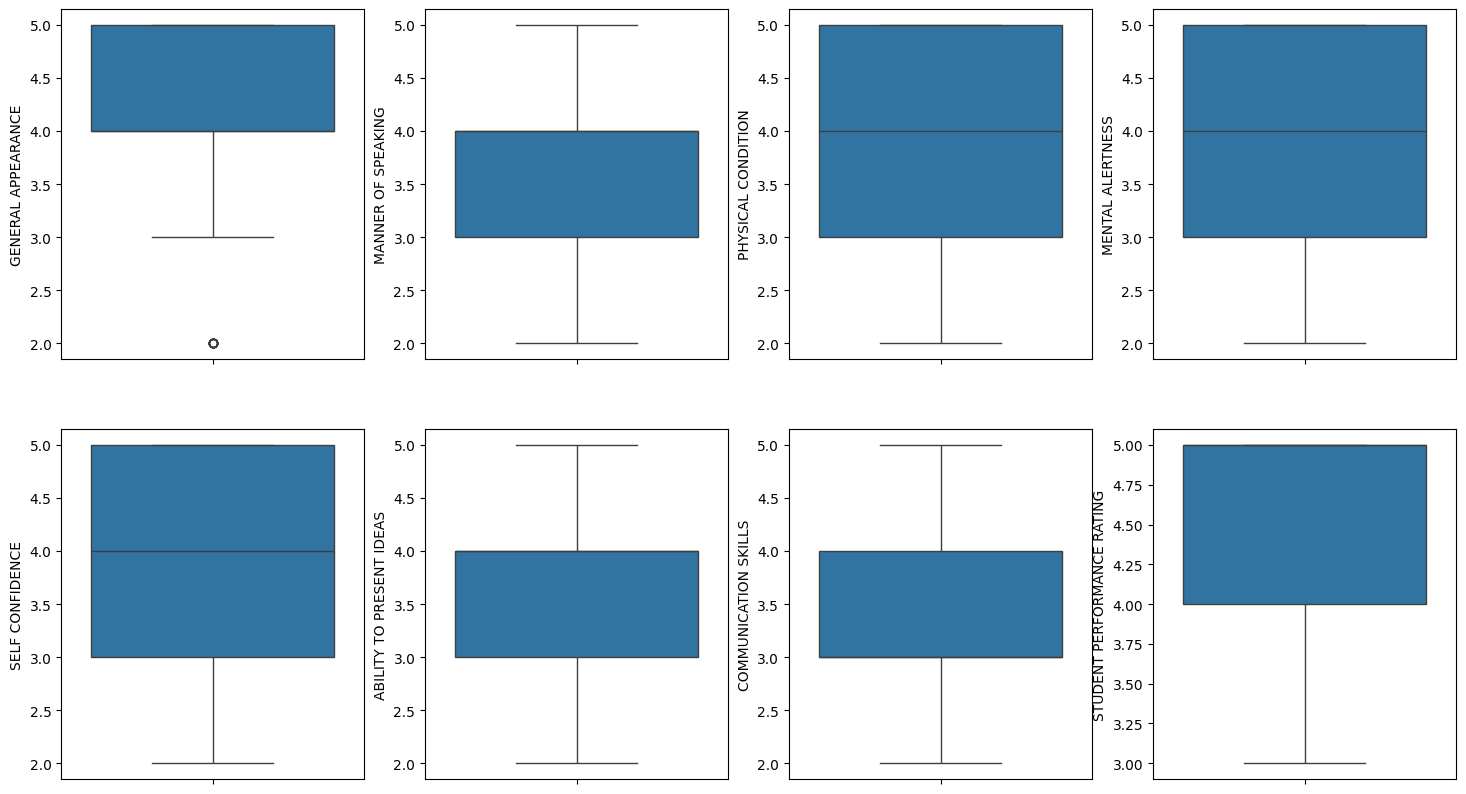

In [ ]:
#OUTLIERS

fig, ax= plt.subplots(2,4, figsize= (18,10))
sns.boxplot(df, y= 'GENERAL APPEARANCE', ax= ax[0][0])
sns.boxplot(df, y= 'MANNER OF SPEAKING', ax= ax[0][1])
sns.boxplot(df, y= 'PHYSICAL CONDITION', ax= ax[0][2])
sns.boxplot(df, y= 'MENTAL ALERTNESS', ax= ax[0][3])
sns.boxplot(df, y= 'SELF CONFIDENCE', ax= ax[1][0])
sns.boxplot(df, y= 'ABILITY TO PRESENT IDEAS', ax= ax[1][1])
sns.boxplot(df, y= 'COMMUNICATION SKILLS', ax= ax[1][2])
sns.boxplot(df, y= 'STUDENT PERFORMANCE RATING', ax= ax[1][3])
plt.show()

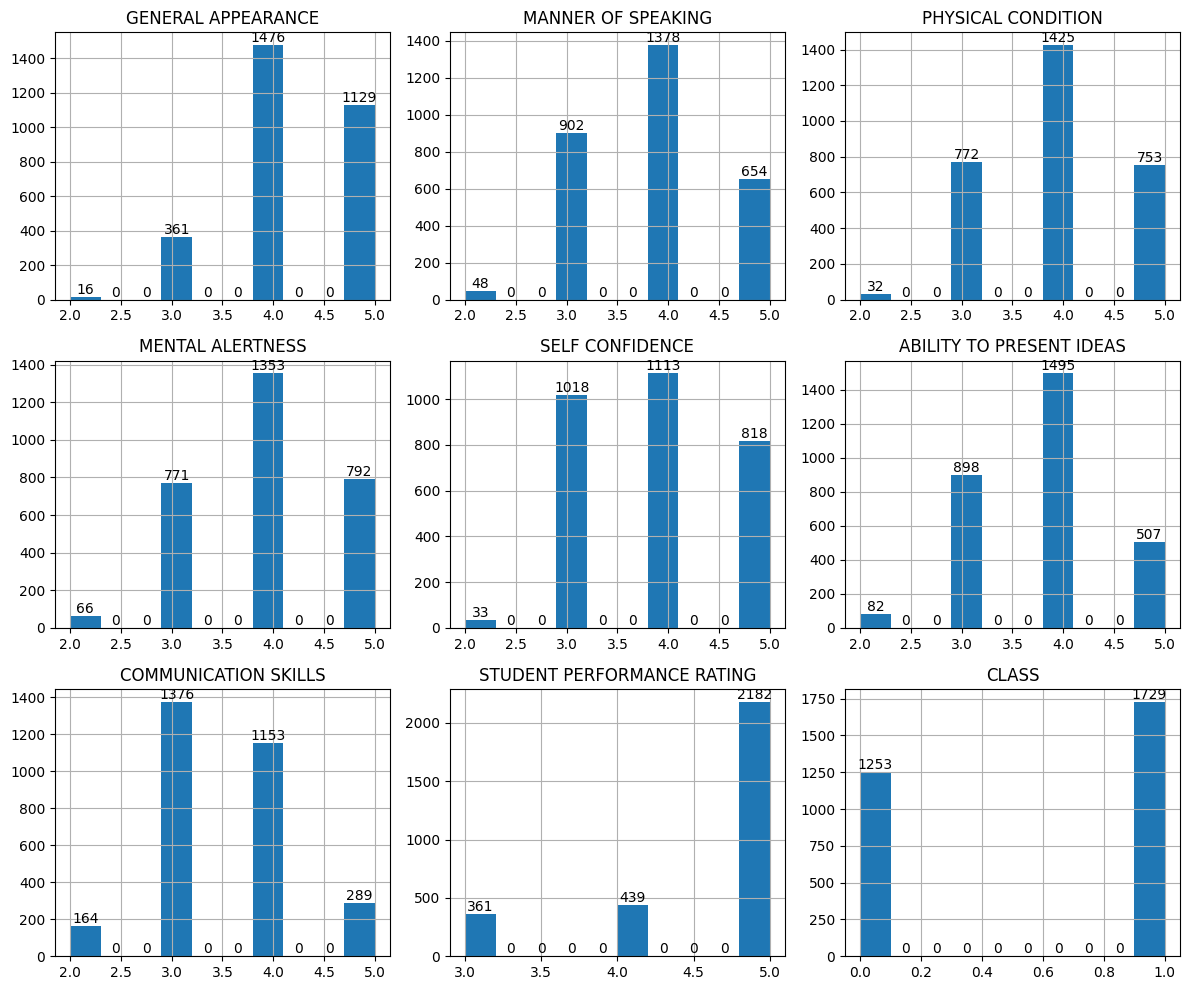

In [ ]:
axes = df.hist(figsize=(12,10))

for ax in axes.ravel():
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

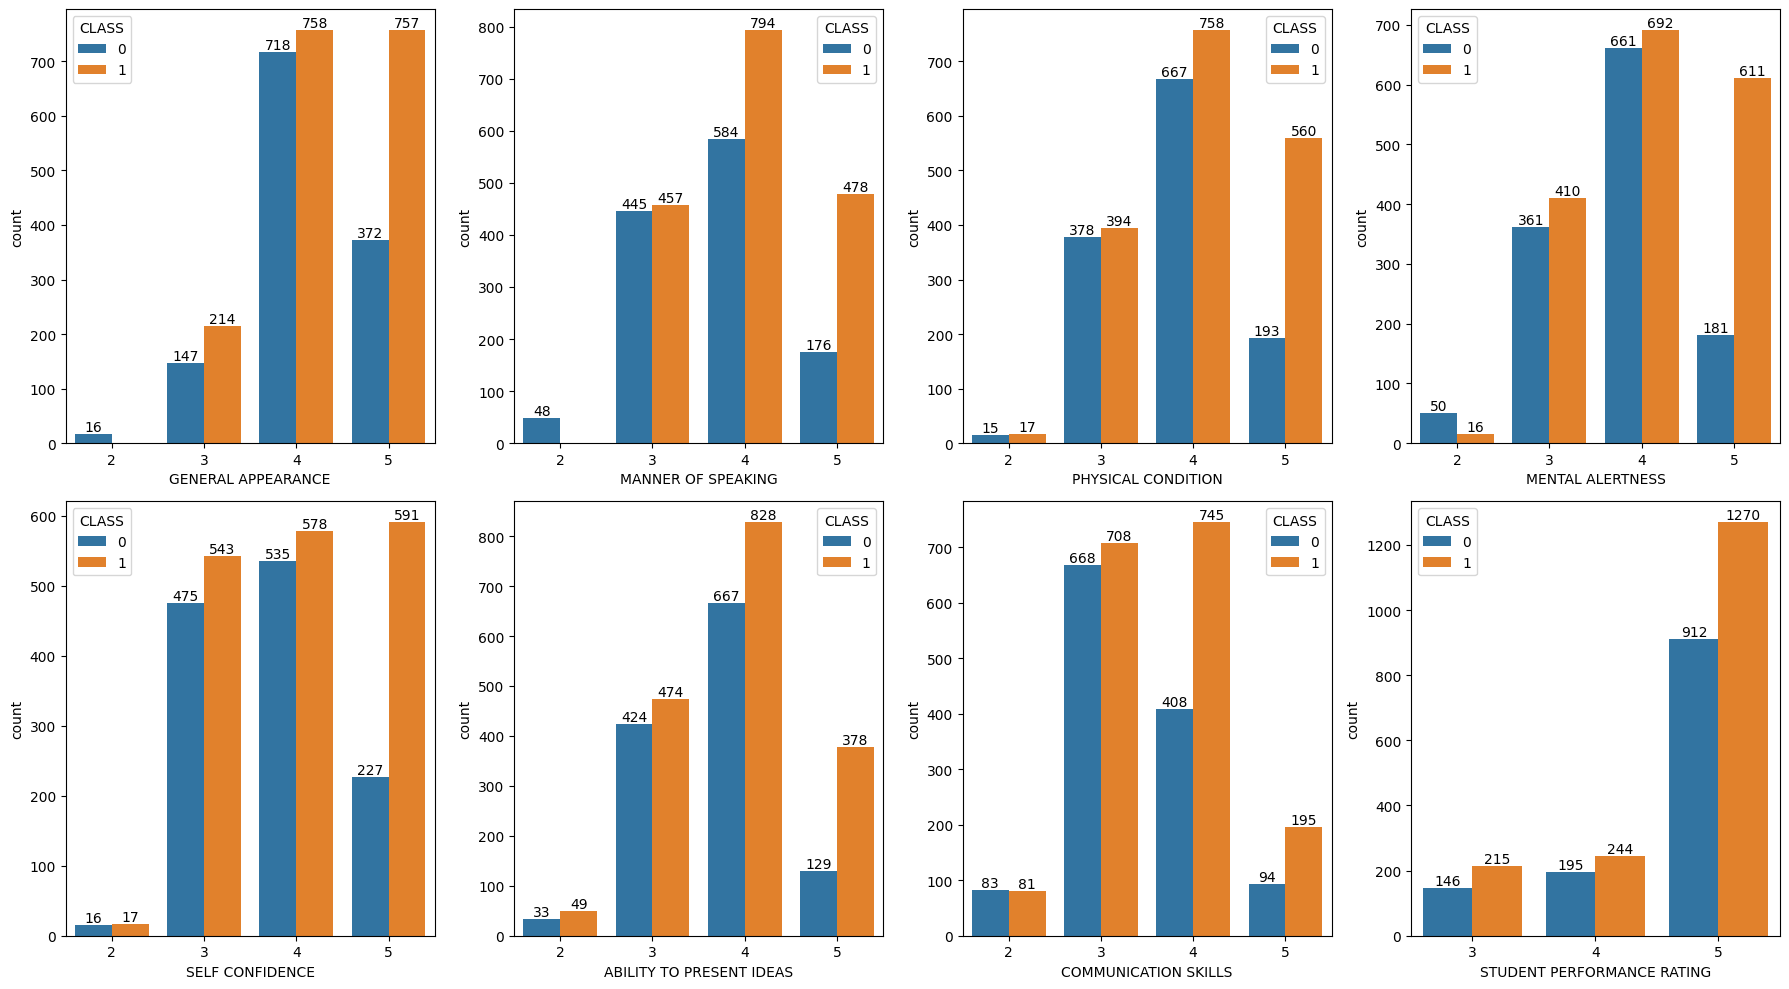

In [ ]:
fig, ax= plt.subplots(2,4, figsize= (18,10))
sns.countplot(df, x= 'GENERAL APPEARANCE', hue='CLASS', ax= ax[0][0])
sns.countplot(df, x= 'MANNER OF SPEAKING', hue='CLASS', ax= ax[0][1])
sns.countplot(df, x= 'PHYSICAL CONDITION', hue='CLASS', ax= ax[0][2])
sns.countplot(df, x= 'MENTAL ALERTNESS', hue='CLASS', ax= ax[0][3])
sns.countplot(df, x= 'SELF CONFIDENCE', hue='CLASS', ax= ax[1][0])
sns.countplot(df, x= 'ABILITY TO PRESENT IDEAS', hue='CLASS', ax= ax[1][1])
sns.countplot(df, x= 'COMMUNICATION SKILLS', hue='CLASS', ax= ax[1][2])
sns.countplot(df, x= 'STUDENT PERFORMANCE RATING', hue='CLASS', ax= ax[1][3])

for axes in ax.flatten():
    for container in axes.containers:
        axes.bar_label(container)

plt.tight_layout()
plt.show()

### Correlation Heatmap

In [ ]:
num_cols= df.select_dtypes(include=np.number).columns

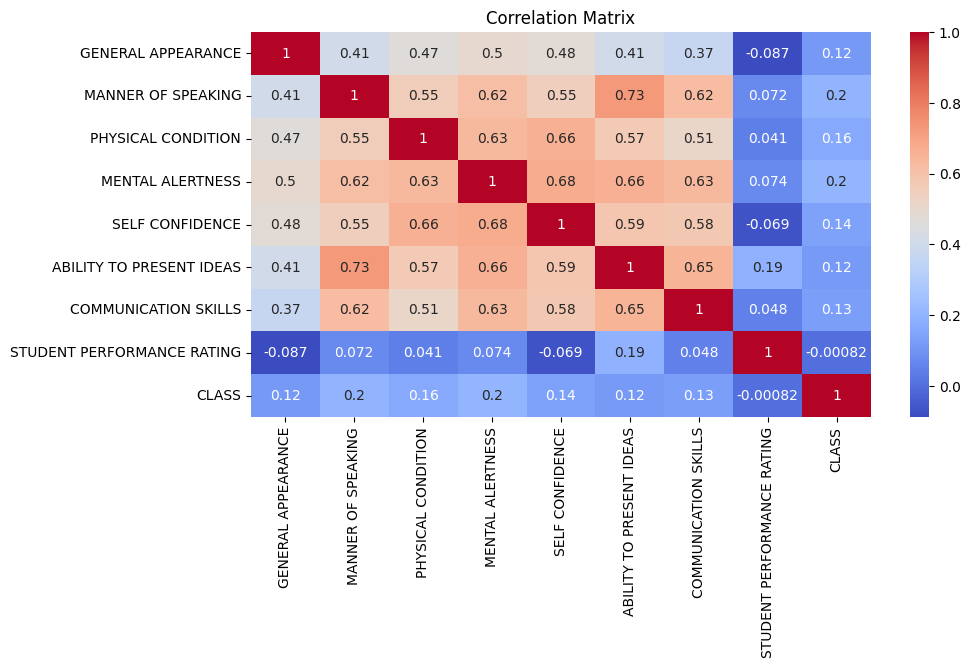

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## EDA Conclusions:

- Clean Dataset: 2982 records × 10 columns (9 features post-drop); zero missing values across all features.

- Feature Insights: 7 soft skills + STUDENT PERFORMANCE RATING show ordinal ratings (2-5 scale, means 3.5-4.6); mildly skewed toward higher values (medians 3-5) with minor outliers in boxplots.

- Target Distribution: Imbalanced binary classification - Employable (1): 1729 (58%), LessEmployable (0): 1253 (42%) - confirmed via countplot; suitable for F1 scoring in modeling.

- Ready for Modeling: High-quality numeric data; no major preprocessing needed beyond encoding and scaling.